In [1]:
# ==========================================
# PHASE 1: Data Cleaning & Warehouse
# ==========================================
import pandas as pd
from sqlalchemy import create_engine
import re
import os

# 1. Load the CSV and filter to English
file_path = r"C:\Users\zeena\OneDrive\Desktop\final project\dataset-tickets-multi-lang-4-20k.csv"

if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}. Please verify the path.")
else:
    df_raw = pd.read_csv(file_path)
    
    # Ensure 'language' column exists before filtering
    if 'language' in df_raw.columns:
        df_en = df_raw[df_raw['language'] == 'en'].copy()
    else:
        print("Warning: 'language' column not found. Processing entire dataset.")
        df_en = df_raw.copy()

    # 2. Inspect: nulls, duplicate tickets, class balance
    print("--- Inspection ---")
    print("Null Values before cleaning:\n", df_en.isnull().sum())

    # The dataset has no ID column, so create one from the original row index
    if 'id' not in df_en.columns:
        df_en = df_en.reset_index().rename(columns={'index': 'id'})

    print(f"Duplicate Tickets (by id): {df_en.duplicated(subset=['id']).sum()}")
    
    if 'queue' in df_en.columns:
        print("Class Balance (Queue):\n", df_en['queue'].value_counts())
    if 'priority' in df_en.columns:
        print("Class Balance (Priority):\n", df_en['priority'].value_counts())

    # 3. Clean subject/body/answer text
    def clean_text(text):
        if pd.isna(text):
            return ""
        text = str(text)
        text = re.sub(r'\s+', ' ', text) # Remove extra whitespace
        return text.strip()

    for col in ['subject', 'body', 'answer']:
        if col in df_en.columns:
            df_en[col] = df_en[col].apply(clean_text)

    # --- NEW: Drop invalid rows BEFORE asserting so the script doesn't crash ---
    if 'answer' in df_en.columns:
        df_en = df_en[df_en['answer'] != ""]
    if 'queue' in df_en.columns:
        df_en = df_en.dropna(subset=['queue'])
    
    df_en = df_en.drop_duplicates(subset=['id'])

    # 4. Data-quality checks
    if 'answer' in df_en.columns:
        assert (df_en['answer'] == "").sum() == 0, "Error: Found empty answer fields"
    if 'queue' in df_en.columns:
        assert df_en['queue'].isnull().sum() == 0, "Error: Found unknown/null queue labels"
    assert df_en.duplicated(subset=['id']).sum() == 0, "Error: Found duplicate ticket IDs"

    # 5. Load the cleaned rows into the tickets table (SQLite)
    engine = create_engine('sqlite:///tickets.db')
    df_en.to_sql('tickets', con=engine, if_exists='replace', index=False)

    print("\nPhase 1 Complete: Cleaned data successfully loaded into tickets.db")

--- Inspection ---
Null Values before cleaning:
 subject      1032
body            1
answer          3
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          10
tag_3          44
tag_4         873
tag_5        4038
tag_6        7385
tag_7        9358
tag_8       10596
dtype: int64
Duplicate Tickets (by id): 0
Class Balance (Queue):
 queue
Technical Support                  3412
Product Support                    2232
Customer Service                   1859
IT Support                         1391
Billing and Payments               1302
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64
Class Balance (Priority):
 priority
medium    4952
high      4571
low       2400
Name: count, dtype: int64

Phase 1 Complete: Cleaned data successfully loaded into tickets.db


Loading data from warehouse...


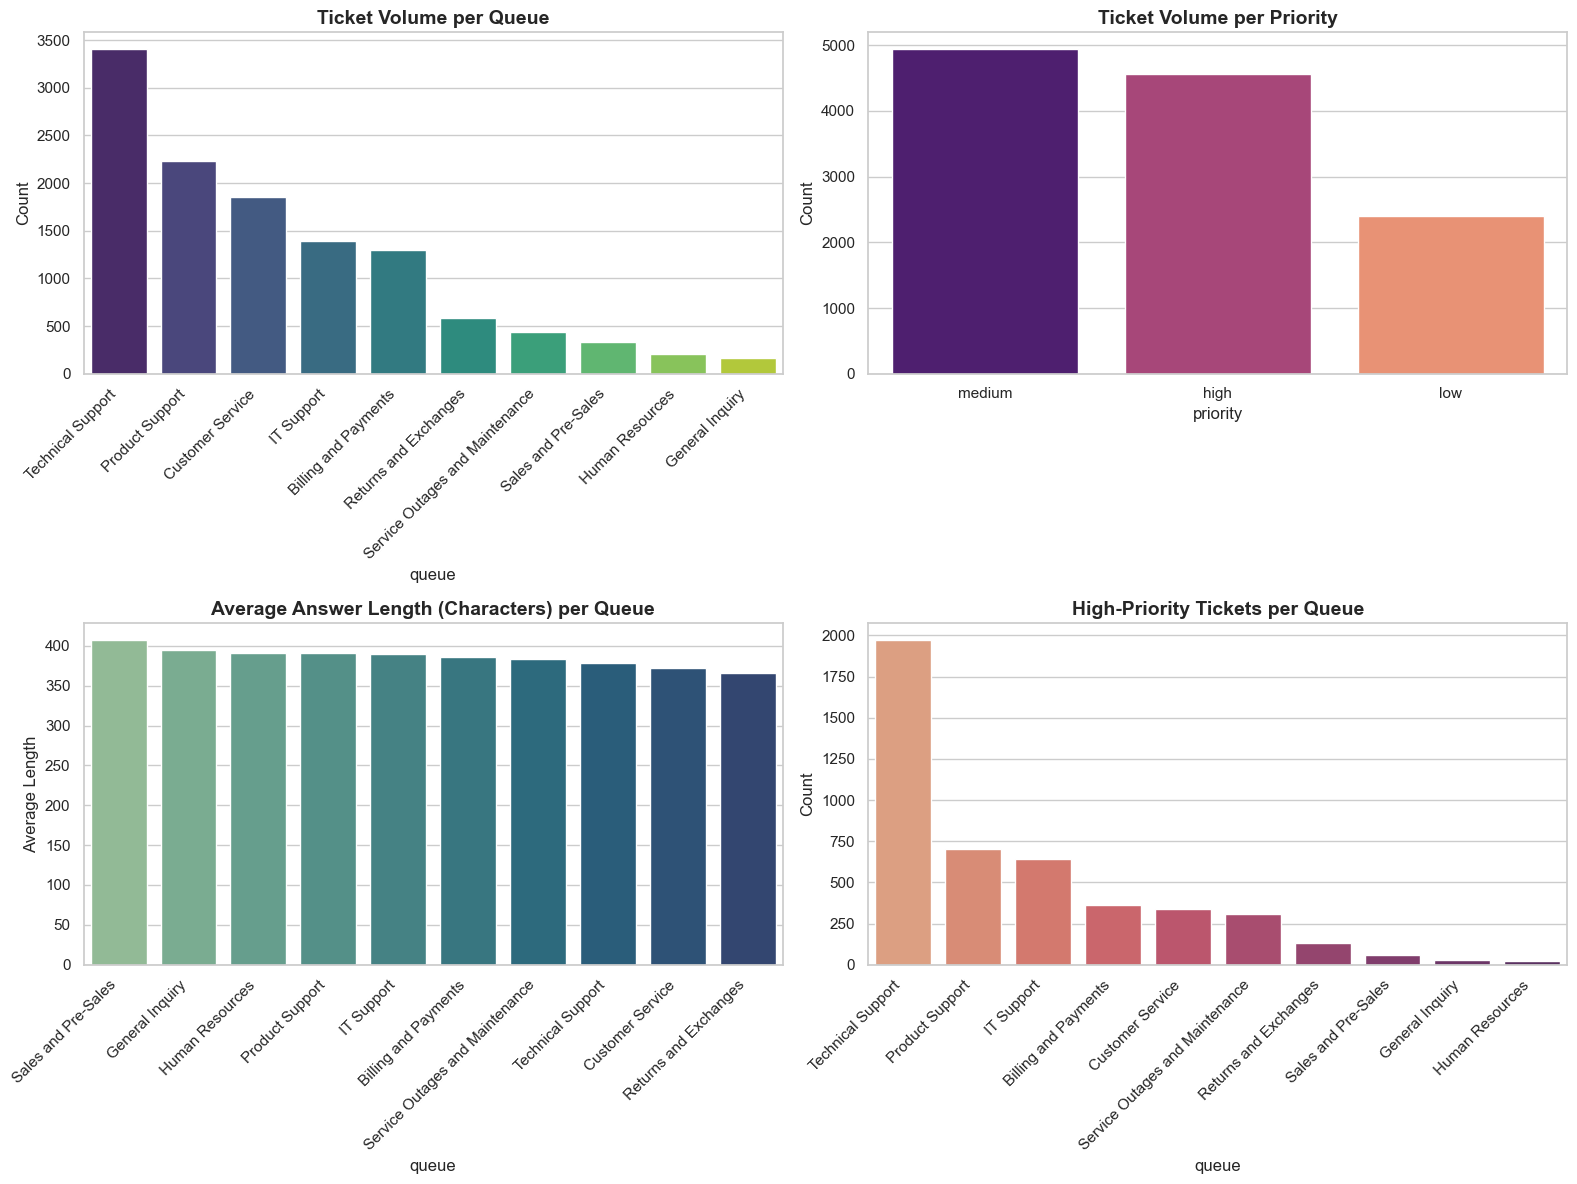

Generating Word Clouds for the top 3 queues...


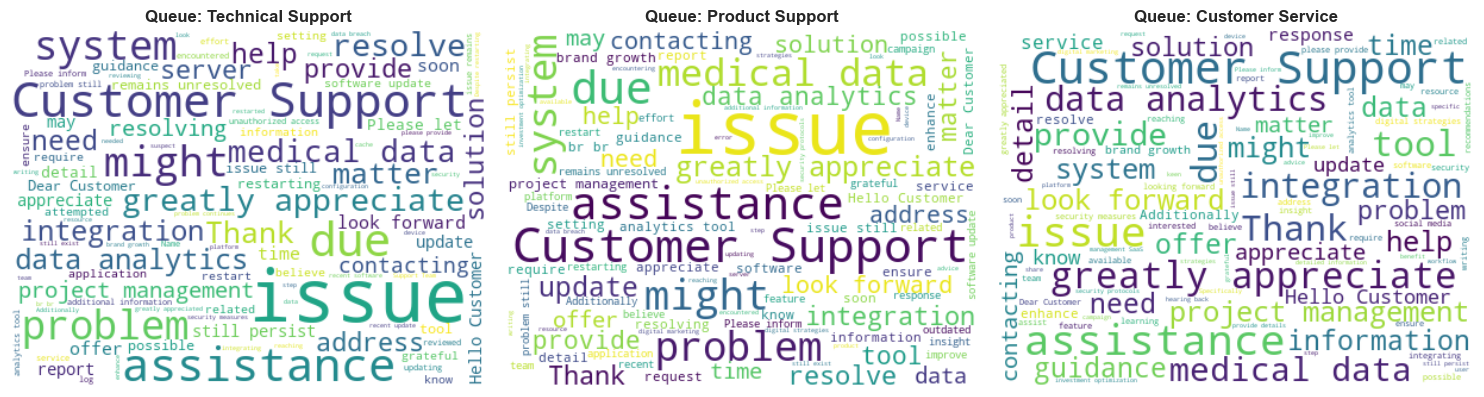

Phase 2 Complete: EDA Visualizations generated successfully.


In [2]:
# ==========================================
# PHASE 2: Analytics EDA
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sqlalchemy import create_engine
import warnings

# Suppress minor warnings for a cleaner notebook output
warnings.filterwarnings('ignore')

print("Loading data from warehouse...")
# Load data from the database created in Phase 1
engine = create_engine('sqlite:///tickets.db')
df = pd.read_sql('SELECT * FROM tickets', con=engine)

# Set up the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Ticket volume per queue
plt.subplot(2, 2, 1)
queue_order = df['queue'].value_counts().index
sns.countplot(data=df, x='queue', order=queue_order, palette='viridis')
plt.title('Ticket Volume per Queue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

# 2. Ticket volume per priority
plt.subplot(2, 2, 2)
priority_order = df['priority'].value_counts().index
sns.countplot(data=df, x='priority', order=priority_order, palette='magma')
plt.title('Ticket Volume per Priority', fontsize=14, fontweight='bold')
plt.ylabel('Count')

# 3. Which queues have the longest agent answers?
df['answer_length'] = df['answer'].astype(str).apply(len)
plt.subplot(2, 2, 3)
longest_answers = df.groupby('queue')['answer_length'].mean().sort_values(ascending=False)
sns.barplot(x=longest_answers.index, y=longest_answers.values, palette='crest')
plt.title('Average Answer Length (Characters) per Queue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Length')

# 4. Which queues have the most high-priority tickets?
plt.subplot(2, 2, 4)
high_priority = df[df['priority'] == 'high'].groupby('queue').size().sort_values(ascending=False)
if not high_priority.empty:
    sns.barplot(x=high_priority.index, y=high_priority.values, palette='flare')
    plt.title('High-Priority Tickets per Queue', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
else:
    # Fallback just in case there are no high priority tickets
    plt.text(0.5, 0.5, 'No High-Priority Tickets Found', ha='center', va='center')
    plt.title('High-Priority Tickets per Queue', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Word clouds per queue
print("Generating Word Clouds for the top 3 queues...")
# Limiting to top 3 queues to keep the notebook output neat and fast
top_queues = queue_order[:3] 

plt.figure(figsize=(15, 5))
for i, queue_name in enumerate(top_queues, 1):
    # Combine all ticket bodies for this specific queue
    text_data = " ".join(df[df['queue'] == queue_name]['body'].astype(str).tolist())
    
    # Generate the word cloud
    wordcloud = WordCloud(width=400, height=300, background_color='white', max_words=100).generate(text_data)
    
    plt.subplot(1, 3, i)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Queue: {queue_name}', fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Phase 2 Complete: EDA Visualizations generated successfully.")

In [3]:
# ==========================================
# PHASE 3: Triage Classifier (TF-IDF ONLY)
# ==========================================
import pandas as pd
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
import joblib
import json
import datetime
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Loading data from warehouse...")
engine = create_engine('sqlite:///tickets.db')
df = pd.read_sql('SELECT * FROM tickets', con=engine)
print(df.columns.tolist())

# Ensure no nulls in text fields before concatenating
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df['text_features'] = df['subject'] + " " + df['body']

# Train/Test Split (Stratified by Queue)
X_train, X_test, y_queue_train, y_queue_test, y_prio_train, y_prio_test, y_category_train, y_category_test = train_test_split(
    df['text_features'], 
    df['queue'], 
    df['priority'],
    df['type'],
    test_size=0.2, 
    random_state=42, 
    stratify=df['queue']
)
print("\n--- Training TF-IDF Baselines ---")
# 1. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 2. Majority-Class Baseline (Queue)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_tfidf, y_queue_train)
dummy_preds = dummy.predict(X_test_tfidf)
dummy_acc = accuracy_score(y_queue_test, dummy_preds)
dummy_f1 = f1_score(y_queue_test, dummy_preds, average='macro')

# 3. Logistic Regression Baseline (Queue)
clf_queue = LogisticRegression(max_iter=1000, random_state=42)
clf_queue.fit(X_train_tfidf, y_queue_train)
queue_preds = clf_queue.predict(X_test_tfidf)
tfidf_queue_acc = accuracy_score(y_queue_test, queue_preds)
tfidf_queue_f1 = f1_score(y_queue_test, queue_preds, average='macro')

# 4. Logistic Regression Baseline (Priority)
clf_prio = LogisticRegression(max_iter=1000, random_state=42)
clf_prio.fit(X_train_tfidf, y_prio_train)
prio_preds = clf_prio.predict(X_test_tfidf)
tfidf_prio_acc = accuracy_score(y_prio_test, prio_preds)
tfidf_prio_f1 = f1_score(y_prio_test, prio_preds, average='macro')

# 5. Logistic Regression (Category / Type)
clf_category = LogisticRegression(max_iter=1000, random_state=42)

clf_category.fit(X_train_tfidf, y_category_train)

category_preds = clf_category.predict(X_test_tfidf)

tfidf_category_acc = accuracy_score(y_category_test, category_preds)

tfidf_category_f1 = f1_score(
    y_category_test,
    category_preds,
    average='macro'
)

print("\n--- CATEGORY CLASSIFICATION ---")
print("Accuracy:", round(tfidf_category_acc, 4))
def safe_round(value):
    return round(float(value), 4)

print("Accuracy:", safe_round(tfidf_category_acc))
print("Macro-F1:", safe_round(tfidf_category_f1))

leaderboard = pd.DataFrame([
    {"Model": "Majority Class", "Accuracy": safe_round(dummy_acc), "Macro-F1": safe_round(dummy_f1)},
    {"Model": "TF-IDF + LR", "Accuracy": safe_round(tfidf_queue_acc), "Macro-F1": safe_round(tfidf_queue_f1)}
])

# 5. Leaderboard Output
print("\n--- LEADERBOARD (Queue Classification) ---")
leaderboard = pd.DataFrame([
    {"Model": "Majority Class", "Accuracy": round(dummy_acc, 4), "Macro-F1": round(dummy_f1, 4)},
    {"Model": "TF-IDF + LR", "Accuracy": round(tfidf_queue_acc, 4), "Macro-F1": round(tfidf_queue_f1, 4)}
])
print(leaderboard.to_string(index=False))

# 6. Save Model Artifacts for Phase 4 API
print("\nSaving fallback winning models (TF-IDF baselines)...")
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(clf_queue, 'clf_queue.joblib')
joblib.dump(clf_prio, 'clf_prio.joblib')
joblib.dump(clf_category, 'clf_category.joblib')

# Save metadata
metadata = {
    "training_date": datetime.datetime.now().isoformat(),
    "model_type": "TF-IDF + LogisticRegression",
    "queue_metrics": {"accuracy": tfidf_queue_acc, "macro_f1": tfidf_queue_f1}
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Phase 3 Complete: Models and metadata successfully saved.")

Loading data from warehouse...
['id', 'subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

--- Training TF-IDF Baselines ---

--- CATEGORY CLASSIFICATION ---
Accuracy: 0.8066
Accuracy: 0.8066
Macro-F1: 0.7875

--- LEADERBOARD (Queue Classification) ---
         Model  Accuracy  Macro-F1
Majority Class    0.2861    0.0445
   TF-IDF + LR    0.4476    0.3183

Saving fallback winning models (TF-IDF baselines)...
Phase 3 Complete: Models and metadata successfully saved.


In [4]:
%%writefile api.py
# ==========================================
# PHASE 4: FastAPI: Triage & Analytics
# ==========================================
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from sqlalchemy import create_engine
import pandas as pd
import joblib

app = FastAPI(title="Support Intelligence API")

# Enable CORS for the React frontend
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allows all origins for local development
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

engine = create_engine('sqlite:///tickets.db')

# Load Phase 3 models (TF-IDF fallback)
try:
    tfidf = joblib.load('tfidf_vectorizer.joblib')
    clf_queue = joblib.load('clf_queue.joblib')
    clf_prio = joblib.load('clf_prio.joblib')
except Exception as e:
    print(f"Warning: Could not load models. {e}")

class TriageRequest(BaseModel):
    subject: str
    body: str

@app.get("/health")
def health_check():
    """Liveness + DB connectivity"""
    try:
        with engine.connect() as conn:
            return {"status": "ok", "db_connected": True}
    except Exception as e:
        return {"status": "error", "message": str(e)}

@app.get("/stats")
def get_stats():
    """Ticket volume per queue, priority distribution"""
    df = pd.read_sql('SELECT queue, priority FROM tickets', con=engine)
    return {
        "queue_volume": df['queue'].value_counts().to_dict(),
        "priority_distribution": df['priority'].value_counts().to_dict()
    }

@app.get("/tickets")
def get_tickets(queue: str = None, priority: str = None, limit: int = 10):
    """List/filter tickets"""
    query = "SELECT * FROM tickets WHERE 1=1"
    if queue:
        query += f" AND queue = '{queue}'"
    if priority:
        query += f" AND priority = '{priority}'"
    query += f" LIMIT {limit}"
    
    df = pd.read_sql(query, con=engine)
    return df.to_dict(orient="records")

@app.post("/triage")
def triage_ticket(request: TriageRequest):
    """Returns predicted queue, priority, and confidence"""
    text_feature = request.subject + " " + request.body
    vec = tfidf.transform([text_feature])
    
    queue_pred = clf_queue.predict(vec)[0]
    queue_conf = max(clf_queue.predict_proba(vec)[0])
    
    prio_pred = clf_prio.predict(vec)[0]
    prio_conf = max(clf_prio.predict_proba(vec)[0])
    
    return {
        "predicted_queue": queue_pred,
        "queue_confidence": float(queue_conf),
        "predicted_priority": prio_pred,
        "priority_confidence": float(prio_conf)
    }

Overwriting api.py


In [5]:
# ==========================================
# TEST PHASE 4 API
# ==========================================
from fastapi.testclient import TestClient
import json

# Import the app you just saved to api.py
try:
    from api import app
    
    client = TestClient(app)
    
    print("--- Testing /health ---")
    response = client.get("/health")
    print(response.json())
    
    print("\n--- Testing /triage ---")
    test_ticket = {
        "subject": "Cannot log in to my account",
        "body": "Hi, I keep getting a password error even though I reset it."
    }
    response = client.post("/triage", json=test_ticket)
    print(json.dumps(response.json(), indent=2))
    
    print("\nPhase 4 Complete: API endpoints are functioning correctly!")

except ImportError:
    print("Error: Could not import 'api.py'. Make sure you ran the %%writefile cell above.")

--- Testing /health ---
{'status': 'ok', 'db_connected': True}

--- Testing /triage ---
{
  "predicted_queue": "Technical Support",
  "queue_confidence": 0.27458477216368266,
  "predicted_priority": "medium",
  "priority_confidence": 0.4727023590304331
}

Phase 4 Complete: API endpoints are functioning correctly!


In [6]:
# ==========================================
# PHASE 5: RAG Index
# ==========================================

import pandas as pd
from sqlalchemy import create_engine
from sentence_transformers import SentenceTransformer
import faiss
import pickle
import numpy as np
import warnings

warnings.filterwarnings('ignore')


# ==========================================
# 1. LOAD DATA
# ==========================================

print("1. Loading data from warehouse...")

engine = create_engine('sqlite:///tickets.db')

df = pd.read_sql(
    'SELECT id, subject, body, answer, queue, priority FROM tickets',
    con=engine
)


# ==========================================
# 2. CLEAN DATA
# ==========================================

df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df['answer'] = df['answer'].fillna('')


# ==========================================
# 3. CREATE DOCUMENTS
# ==========================================

print("2. Creating ticket documents...")

df['chunk_text'] = (
    "Subject: " + df['subject']
    + "\nBody: " + df['body']
    + "\nAnswer: " + df['answer']
)

docs = df['chunk_text'].tolist()


# ==========================================
# 4. LOAD EMBEDDING MODEL
# ==========================================

print("3. Loading embedding model...")

embedder = SentenceTransformer(
    'all-MiniLM-L6-v2'
)


# ==========================================
# 5. CREATE NORMALIZED EMBEDDINGS
# ==========================================

print("4. Creating embeddings...")

embeddings = embedder.encode(
    docs,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings = embeddings.astype('float32')


# ==========================================
# 6. BUILD FAISS INDEX
# ==========================================

print("5. Building FAISS index...")

dimension = embeddings.shape[1]

# Inner Product on normalized vectors
# = Cosine Similarity

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

faiss.write_index(
    index,
    "tickets_rag.index"
)


# ==========================================
# 7. SAVE METADATA
# ==========================================

print("6. Saving metadata...")

metadata = df[
    ['id', 'queue', 'priority', 'answer']
].to_dict(orient='records')

with open(
    'rag_metadata.pkl',
    'wb'
) as f:

    pickle.dump(
        metadata,
        f
    )


# ==========================================
# 8. RETRIEVAL FUNCTION
# ==========================================

def retrieve(
    query: str,
    k: int = 3,
    queue_filter: str | None = None,
    threshold: float = 0.45
):
    """
    Retrieves the most semantically similar support tickets
    using cosine similarity.
    """

    query_vector = embedder.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype('float32')

    fetch_k = k * 5 if queue_filter else k

    distances, indices = index.search(
        query_vector,
        fetch_k
    )

    results = []

    for score, idx in zip(distances[0], indices[0]):

        if idx < 0 or score < threshold:
            continue

        meta = metadata[idx]

        if queue_filter is not None and meta['queue'] != queue_filter:
            continue

        results.append({
            "ticket_id": meta['id'],
            "queue": meta['queue'],
            "priority": meta['priority'],
            "answer": meta['answer'],
            "score": float(score)
        })

        if len(results) >= k:
            break

    return results


# ==========================================
# 9. TEST RETRIEVAL
# ==========================================

print("\n--- Testing Retrieval ---")

test_queries = [
    "How do I reset my password?",
    "My payment was declined. What should I do?",
    "I cannot log into my account.",
    "I was charged the wrong amount."
]


for test_query in test_queries:

    print("\n----------------------------------")
    print(f"Query: {test_query}")

    test_results = retrieve(
        test_query,
        k=3
    )

    if not test_results:

        print(
            "No relevant tickets found."
        )

    else:

        for res in test_results:

            print(
                f"Ticket ID: {res['ticket_id']} "
                f"| Similarity: {res['score']:.4f}"
            )

            print(
                f"Queue: {res['queue']} "
                f"| Priority: {res['priority']}"
            )

            print(
                f"Answer: "
                f"{res['answer'][:150]}..."
            )


print("\nPhase 5 Complete!")

1. Loading data from warehouse...
2. Creating ticket documents...
3. Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

4. Creating embeddings...
5. Building FAISS index...
6. Saving metadata...

--- Testing Retrieval ---

----------------------------------
Query: How do I reset my password?
Ticket ID: 8442 | Similarity: 0.5014
Queue: Returns and Exchanges | Priority: medium
Answer: We regret the inconvenience caused. Thank you for promptly addressing the issue. A representative will contact you to further discuss and offer additi...
Ticket ID: 8320 | Similarity: 0.4859
Queue: Customer Service | Priority: medium
Answer: Kindly clear your browser's cache and attempt to log in again...

----------------------------------
Query: My payment was declined. What should I do?
Ticket ID: 9052 | Similarity: 0.5550
Queue: Billing and Payments | Priority: medium
Answer: We apologize for the inconvenience you're experiencing with your subscription payment. We appreciate that you've checked your card details to ensure t...
Ticket ID: 12655 | Similarity: 0.5300
Queue: Billing and Payments | Priority: medium
Answer: De

In [7]:
# ==========================================
# PHASE 6.1: Initialize Chat Logs Table
# ==========================================
from sqlalchemy import create_engine, text

engine = create_engine('sqlite:///tickets.db')
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS chat_logs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            session_id TEXT,
            role TEXT,
            message TEXT,
            cited_ticket_ids TEXT,
            tool_used TEXT,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """))
print("chat_logs table verified/created in tickets.db!")

chat_logs table verified/created in tickets.db!


In [8]:
%%writefile api.py
# ==========================================
# PHASE 4, 5 & 6: The Complete FastAPI Server
# ==========================================
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List, Optional
from sqlalchemy import create_engine, text
import pandas as pd
import joblib
import faiss
import pickle
from sentence_transformers import SentenceTransformer
import numpy as np
from openai import OpenAI
import json
import datetime

app = FastAPI(title="Support Intelligence API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], 
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# --- 1. Load Resources ---
engine = create_engine('sqlite:///tickets.db')

# ML Models
try:
    tfidf = joblib.load('tfidf_vectorizer.joblib')
    clf_queue = joblib.load('clf_queue.joblib')
    clf_prio = joblib.load('clf_prio.joblib')
except:
    pass

# RAG Index
embedder = SentenceTransformer('all-MiniLM-L6-v2')
rag_index = faiss.read_index("tickets_rag.index")
with open('rag_metadata.pkl', 'rb') as f:
    rag_metadata = pickle.load(f)

# LLM Client (Replace with your chosen provider/key)
# If using a free OpenAI-compatible API (like Groq or GitHub Models), change the base_url.
client = OpenAI(api_key="YOUR_API_KEY_HERE") 

# --- 2. Pydantic Models ---
class TriageRequest(BaseModel):
    subject: str
    body: str

class ChatMessage(BaseModel):
    role: str
    content: str

class ChatRequest(BaseModel):
    session_id: str
    messages: List[ChatMessage]

# --- 3. Phase 6 Tools ---
def search_similar_tickets(query: str, k: int = 3):
    """Tool 1: Searches the FAISS index for similar past tickets."""
    query_vector = embedder.encode([query], convert_to_numpy=True)
    distances, indices = rag_index.search(query_vector, k)
    
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if dist < 1.5: # Threshold
            meta = rag_metadata[idx]
            results.append({
                "ticket_id": meta['id'],
                "queue": meta['queue'],
                "answer": meta['answer']
            })
    return results

def query_stats():
    """Tool 2: Gets high-level stats from the DB."""
    df = pd.read_sql('SELECT queue, priority FROM tickets', con=engine)
    return {
        "queue_counts": df['queue'].value_counts().to_dict(),
        "priority_counts": df['priority'].value_counts().to_dict()
    }

def log_chat(session_id: str, role: str, message: str, cited_ids: str = None, tool_used: str = None):
    """Database logging helper for the chat loop."""
    with engine.begin() as conn:
        conn.execute(text("""
            INSERT INTO chat_logs (session_id, role, message, cited_ticket_ids, tool_used)
            VALUES (:session_id, :role, :message, :cited_ids, :tool_used)
        """), {
            "session_id": session_id, "role": role, "message": message, 
            "cited_ids": cited_ids, "tool_used": tool_used
        })

# --- 4. API Endpoints ---
@app.get("/health")
def health_check():
    return {"status": "ok"}

@app.get("/stats")
def get_stats():
    return query_stats()

@app.post("/triage")
def triage_ticket(request: TriageRequest):
    text_feature = request.subject + " " + request.body
    vec = tfidf.transform([text_feature])
    return {
        "predicted_queue": clf_queue.predict(vec)[0],
        "queue_confidence": float(max(clf_queue.predict_proba(vec)[0])),
        "predicted_priority": clf_prio.predict(vec)[0]
    }

@app.post("/chat")
def chat_endpoint(request: ChatRequest):
    """Phase 6: Multi-turn Chatbot Loop with Tools and Memory"""
    
    # 1. Log the user's incoming message
    user_msg = request.messages[-1].content
    log_chat(request.session_id, "user", user_msg)
    
    # 2. Setup System Prompt (Grounding Rules)
    system_prompt = """You are an AI support-desk assistant. You have two tools available.
    If the user asks for troubleshooting help, use SEARCH_TICKETS to find similar past cases.
    If the user asks about ticket data or counts, use QUERY_STATS.
    
    CRITICAL RULES:
    1. NEVER invent a solution. Answer ONLY based on retrieved tool context.
    2. ALWAYS cite the ticket ID used (e.g., 'Source: ticket #1234').
    3. If search returns no relevant results, explicitly state: 'I don't have a similar case for that.'
    4. Do not leak personal customer data.
    5. If a question is not support-related (e.g., 'What is the capital of France?'), decline to answer.
    
    To use a tool, output exactly one of these commands and nothing else:
    TOOL: SEARCH_TICKETS | <your search query>
    TOOL: QUERY_STATS
    """
    
    # 3. Format history for the LLM
    llm_messages = [{"role": "system", "content": system_prompt}]
    for msg in request.messages:
        llm_messages.append({"role": msg.role, "content": msg.content})
        
    # 4. First LLM Pass: Decide if a tool is needed (or handle follow-ups)
    response = client.chat.completions.create(
        model="gpt-3.5-turbo", # Change based on your API provider
        messages=llm_messages,
        temperature=0.0
    )
    
    ai_output = response.choices[0].message.content
    
    tool_used = "None"
    cited_ids = ""
    
    # 5. Tool Execution Loop
    if ai_output.startswith("TOOL: SEARCH_TICKETS"):
        tool_used = "search_similar_tickets"
        search_query = ai_output.split("|")[1].strip()
        search_results = search_similar_tickets(search_query)
        
        if not search_results:
            final_answer = "I don't have a similar case for that."
        else:
            # Extract cited IDs for logging
            cited_ids = ", ".join([str(res['ticket_id']) for res in search_results])
            
            # Pass results back to LLM for final generation
            llm_messages.append({"role": "assistant", "content": ai_output})
            llm_messages.append({"role": "system", "content": f"Tool Results:\n{json.dumps(search_results)}"})
            
            final_resp = client.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=llm_messages,
                temperature=0.0
            )
            final_answer = final_resp.choices[0].message.content

    elif ai_output.startswith("TOOL: QUERY_STATS"):
        tool_used = "query_stats"
        stats = query_stats()
        
        llm_messages.append({"role": "assistant", "content": ai_output})
        llm_messages.append({"role": "system", "content": f"Tool Results:\n{json.dumps(stats)}"})
        
        final_resp = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=llm_messages,
            temperature=0.0
        )
        final_answer = final_resp.choices[0].message.content
        
    else:
        # LLM decided no tool was needed (e.g., rejecting a non-support question)
        final_answer = ai_output
        
    # 6. Log Assistant's final answer
    log_chat(request.session_id, "assistant", final_answer, cited_ids=cited_ids, tool_used=tool_used)
    
    return {
        "answer": final_answer,
        "cited_ticket_ids": cited_ids,
        "tool_used": tool_used
    }

Overwriting api.py
